HANDWRITTEN DIGIT RECOGNITION SYSTEM

In [48]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [49]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("New training data shape:", x_train.shape)
print("New label shape:", y_train.shape)


New training data shape: (60000, 28, 28, 1)
New label shape: (60000, 10)


In [50]:
model = models.Sequential([
    # Minimal augmentation for robust learning
    layers.RandomRotation(0.1),
    
    # Layer 1: Extract edges and basic shapes
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1), kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Layer 2: Extract mid-level features
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Dense layers with proper regularization
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_5               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.05, momentum=0.95, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=0, 
    validation_data=(x_test, y_test),
    verbose=1
)

NUMBER RECOGNIER 

In [52]:
model.save('digit_model.h5')
print("Model saved")

Model saved


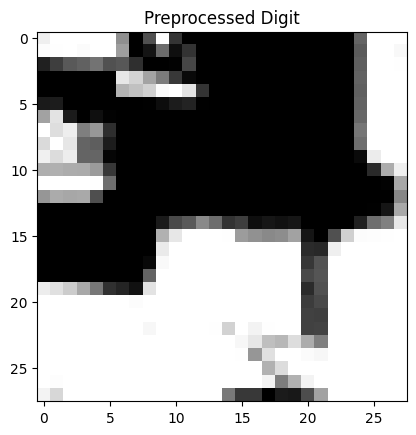

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("captured_digit.png")

# Check if image was loaded successfully
if img is None:
    raise FileNotFoundError("captured_digit.png not found. Please run capture.py first to capture a digit.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w*h > 100:  # ignore very small noise
        digit = thresh[y:y+h, x:x+w]
        break

resized = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)

resized = resized.astype('float32') / 255.0
resized = np.reshape(resized, (1, 28, 28, 1))

plt.imshow(resized.reshape(28, 28), cmap='gray')
plt.title("Preprocessed Digit")
plt.show()

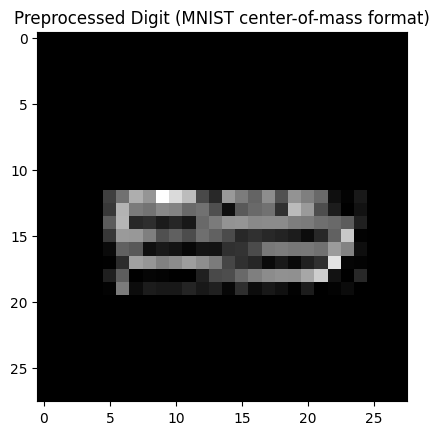

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread("captured_digit.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# # Morphological closing and dilation to thicken digit lines (matches MNIST brush strokes)
# kernel = np.ones((3,3), np.uint8)
# thresh = cv2.dilate(thresh, kernel, iterations=1)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered = [c for c in contours if cv2.contourArea(c) > 150]

if len(filtered) == 0:
    raise ValueError("No clear digit found!")

largest_contour = max(filtered, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

# Add small padding to bounding box
padding = 10
img_h, img_w = thresh.shape
x = max(0, x - padding)
y = max(0, y - padding)
w = min(img_w - x, w + 2*padding)
h = min(img_h - y, h + 2*padding)

# Extract the bounding box round the digit
digit = thresh[y:y+h, x:x+w]

# Center using center of mass to match MNIST tightly
side = max(w, h)
scale_factor = 20.0 / side
new_w = int(w * scale_factor)
new_h = int(h * scale_factor)

resized_digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

# Calculate center of mass of the scaled digit
M = cv2.moments(resized_digit)
if M["m00"] != 0:
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
else:
    cX, cY = new_w // 2, new_h // 2

# Create a 28x28 black background
final_img = np.zeros((28, 28), dtype=np.uint8)

# Center of mass should be placed in the middle of the 28x28 image (at 14, 14)
# Calculate where the top left corner needs to sit. 
offset_x = 14 - cX
offset_y = 14 - cY

# Bound checks
if offset_x < 0: offset_x = 0
if offset_y < 0: offset_y = 0
if offset_x + new_w > 28: offset_x = 28 - new_w
if offset_y + new_h > 28: offset_y = 28 - new_h

final_img[offset_y:offset_y+new_h, offset_x:offset_x+new_w] = resized_digit

resized = final_img.astype('float32') / 255.0
resized = np.reshape(resized, (1, 28, 28, 1))

plt.imshow(resized.reshape(28, 28), cmap='gray')
plt.title("Preprocessed Digit (MNIST center-of-mass format)")
plt.show()

In [55]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model("digit_model.h5")

prediction = model.predict(resized)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
Predicted Digit: 8


In [ ]:
import os
import pygame
from PyQt5.QtWidgets import QApplication, QMessageBox
from PyQt5.QtCore import Qt

# Ensure prediction exists
try:
    detected_digit = int(predicted_digit)
except NameError:
    raise NameError("predicted_digit not defined. Run the prediction cell first.")

# Initialize pygame mixer
pygame.mixer.init()

# Map digits 1-9 to sound files
sound_map = {
    1: "audio/1.mp3",
    2: "audio/2.mp3",
    3: "audio/3.mp3",
    4: "audio/4.mp3",
    5: "audio/5.mp3",
    6: "audio/6.mp3",
    7: "audio/7.mp3",
    8: "audio/8.mp3",
    9: "audio/9.mp3"
}

# Play sound based on detected digit
if detected_digit == 1:
    sound_file = sound_map[1]
elif detected_digit == 2:
    sound_file = sound_map[2]
elif detected_digit == 3:
    sound_file = sound_map[3]
elif detected_digit == 4:
    sound_file = sound_map[4]
elif detected_digit == 5:
    sound_file = sound_map[5]
elif detected_digit == 6:
    sound_file = sound_map[6]
elif detected_digit == 7:
    sound_file = sound_map[7]
elif detected_digit == 8:
    sound_file = sound_map[8]
elif detected_digit == 9:
    sound_file = sound_map[9]
else:
    print(f"Digit {detected_digit} out of range 1-9")
    sound_file = None

# Play the appropriate sound
if sound_file and os.path.exists(sound_file):
    sound = pygame.mixer.Sound(sound_file)
    sound.play()
    print(f"Playing sound for digit {detected_digit}: {sound_file}")
else:
    print(f"Warning: Sound file {sound_file} not found")

# Show popup with detected digit
from PyQt5.QtWidgets import QDialog, QVBoxLayout, QLabel, QPushButton
from PyQt5.QtGui import QFont
from PyQt5.QtCore import Qt

app = QApplication.instance()
if app is None:
    app = QApplication([])

# Create a custom dialog window
dialog = QDialog()
dialog.setWindowTitle("🎯 DIGIT DETECTION RESULT")
dialog.setGeometry(100, 100, 500, 300)
dialog.setStyleSheet("background-color: #f0f0f0;")

# Main layout
layout = QVBoxLayout()
layout.setSpacing(15)
layout.setContentsMargins(25, 25, 25, 25)

# Title
title_label = QLabel("✨ DIGIT DETECTED ✨")
title_font = QFont("Arial", 18, QFont.Bold)
title_label.setFont(title_font)
title_label.setAlignment(Qt.AlignCenter)
title_label.setStyleSheet("color: #2c3e50;")
layout.addWidget(title_label)

# Detected digit display
detected_label = QLabel(f"DETECTED NUMBER: {detected_digit}")
detected_font = QFont("Arial", 40, QFont.Bold)
detected_label.setFont(detected_font)
detected_label.setAlignment(Qt.AlignCenter)
detected_label.setStyleSheet("color: #27ae60; background-color: white; border-radius: 8px; padding: 15px;")
layout.addWidget(detected_label)

# Message
msg_label = QLabel("Recognition completed successfully.")
msg_font = QFont("Arial", 12)
msg_label.setFont(msg_font)
msg_label.setAlignment(Qt.AlignCenter)
msg_label.setStyleSheet("color: #555;")
layout.addWidget(msg_label)

# OK Button
ok_button = QPushButton("✓ CLOSE")
button_font = QFont("Arial", 11, QFont.Bold)
ok_button.setFont(button_font)
ok_button.setFixedHeight(40)
ok_button.setStyleSheet("""
    QPushButton {
        background-color: #27ae60;
        color: white;
        border-radius: 5px;
        font-weight: bold;
    }
    QPushButton:hover {
        background-color: #2ecc71;
    }
    QPushButton:pressed {
        background-color: #229954;
    }
""")
ok_button.clicked.connect(dialog.accept)
layout.addWidget(ok_button)

dialog.setLayout(layout)
dialog.setWindowModality(Qt.ApplicationModal)
dialog.exec_()

In [ ]:
import os
import time
import pygame
import pyttsx3
import numpy as np
from PyQt5.QtWidgets import QApplication, QMessageBox
from PyQt5.QtCore import Qt

# Ensure prediction exists
try:
    detected_digit = int(predicted_digit)
except NameError:
    raise NameError("predicted_digit not defined. Run the prediction cell first.")

# Initialize pygame mixer
pygame.mixer.init()

# ==== FEATURE 1: CONFIDENCE DISPLAY ====
main_confidence = float(prediction[0][detected_digit]) * 100
print(f"\n🎯 DETECTED DIGIT: {detected_digit}")
print(f"📊 Confidence: {main_confidence:.2f}%")

# ==== FEATURE 2: TOP 3 PREDICTIONS ====
top_3_indices = np.argsort(prediction[0])[-3:][::-1]
top_3_predictions = [(int(idx), float(prediction[0][idx]) * 100) for idx in top_3_indices]

print(f"\n🏆 Top 3 Predictions:")
for rank, (digit, conf) in enumerate(top_3_predictions, 1):
    print(f"   {rank}. Digit {digit}: {conf:.2f}%")

# ==== FEATURE 3: VOICE ANNOUNCEMENT ====
try:
    engine = pyttsx3.init()
    engine.setProperty('rate', 150)  # Speaking speed
    engine.say(f"The detected digit is {detected_digit}")
    engine.runAndWait()
    print("🔊 Voice announcement played")
except Exception as e:
    print(f"⚠️  Could not initialize voice: {e}")

# Play report ready audio
report_file = "audio/report.mp3"
if os.path.exists(report_file):
    try:
        sound = pygame.mixer.Sound(report_file)
        sound.play()
        print("🔊 Report ready audio playing...")
    except Exception as e:
        print(f"Could not play report audio: {e}")
else:
    print(f"⚠️ Report audio not found: {report_file}")

# ==== CREATE PROFESSIONAL CUSTOM DIALOG ====
from PyQt5.QtWidgets import QDialog, QVBoxLayout, QLabel, QPushButton
from PyQt5.QtGui import QFont, QPixmap, QColor
from PyQt5.QtCore import Qt, QSize

app = QApplication.instance()
if app is None:
    app = QApplication([])

# Create a custom dialog
dialog = QDialog()
dialog.setWindowTitle("🎯 DIGIT DETECTION RESULT")
dialog.setGeometry(100, 100, 700, 600)
dialog.setStyleSheet("background-color: #f0f0f0;")

# Main layout
layout = QVBoxLayout()
layout.setSpacing(20)
layout.setContentsMargins(30, 30, 30, 30)

# ===== TITLE =====
title_label = QLabel("✨ DIGIT DETECTION SYSTEM ✨")
title_font = QFont("Arial", 20, QFont.Bold)
title_label.setFont(title_font)
title_label.setAlignment(Qt.AlignCenter)
title_label.setStyleSheet("color: #2c3e50; padding: 10px;")
layout.addWidget(title_label)

# ===== DETECTED DIGIT (Large) =====
detected_label = QLabel(f"DETECTED DIGIT: {detected_digit}")
detected_font = QFont("Arial", 48, QFont.Bold)
detected_label.setFont(detected_font)
detected_label.setAlignment(Qt.AlignCenter)
detected_label.setStyleSheet("color: #27ae60; background-color: white; border-radius: 10px; padding: 20px;")
layout.addWidget(detected_label)

# ===== CONFIDENCE SECTION =====
confidence_title = QLabel("📊 CONFIDENCE LEVEL")
conf_title_font = QFont("Arial", 14, QFont.Bold)
confidence_title.setFont(conf_title_font)
confidence_title.setStyleSheet("color: #2980b9;")
layout.addWidget(confidence_title)

confidence_bar = "█" * int(main_confidence / 5) + "░" * (20 - int(main_confidence / 5))
confidence_text = QLabel(f"{main_confidence:.1f}%\n[{confidence_bar}]")
confidence_font = QFont("Courier", 12)
confidence_text.setFont(confidence_font)
confidence_text.setAlignment(Qt.AlignCenter)
confidence_text.setStyleSheet("background-color: white; padding: 10px; border-radius: 5px;")
layout.addWidget(confidence_text)

# ===== TOP 3 PREDICTIONS =====
top3_title = QLabel("🏆 TOP 3 PREDICTIONS")
top3_title_font = QFont("Arial", 14, QFont.Bold)
top3_title.setFont(top3_title_font)
top3_title.setStyleSheet("color: #e74c3c;")
layout.addWidget(top3_title)

top3_content = QLabel(
    f"""1️⃣  DIGIT {top_3_predictions[0][0]}: {top_3_predictions[0][1]:.1f}%
2️⃣  DIGIT {top_3_predictions[1][0]}: {top_3_predictions[1][1]:.1f}%
3️⃣  DIGIT {top_3_predictions[2][0]}: {top_3_predictions[2][1]:.1f}%"""
)
top3_font = QFont("Arial", 13)
top3_content.setFont(top3_font)
top3_content.setAlignment(Qt.AlignCenter)
top3_content.setStyleSheet("background-color: white; padding: 15px; border-radius: 5px; line-height: 1.8;")
layout.addWidget(top3_content)

# ===== OK BUTTON =====
ok_button = QPushButton("✓ CLOSE")
button_font = QFont("Arial", 12, QFont.Bold)
ok_button.setFont(button_font)
ok_button.setFixedHeight(45)
ok_button.setStyleSheet("""
    QPushButton {
        background-color: #27ae60;
        color: white;
        border-radius: 5px;
        font-weight: bold;
    }
    QPushButton:hover {
        background-color: #2ecc71;
    }
    QPushButton:pressed {
        background-color: #229954;
    }
""")
ok_button.clicked.connect(dialog.accept)
layout.addWidget(ok_button)

dialog.setLayout(layout)
dialog.setWindowModality(Qt.ApplicationModal)
dialog.exec_()


🎯 DETECTED DIGIT: 0
📊 Confidence: 10.18%

🏆 Top 3 Predictions:
   1. Digit 0: 10.18%
   2. Digit 8: 10.11%
   3. Digit 5: 10.10%
⚠️  Could not initialize voice: No module named 'pywintypes'
🔊 Report ready audio playing...


1